Libraries Imported Successfully!
Project Path= C:\Users\sweethome\OneDrive\Desktop\class_work
file path= C:\Users\sweethome\OneDrive\Desktop\class_work\diabetes_data.xlsx
     Pregnancies  Glucose  BloodPressure  SkinThickness  Insulin   BMI  \
0              6      148             72             35        0  33.6   
1              1       85             66             29        0  26.6   
2              8      183             64              0        0  23.3   
3              1       89             66             23       94  28.1   
4              0      137             40             35      168  43.1   
..           ...      ...            ...            ...      ...   ...   
763           10      101             76             48      180  32.9   
764            2      122             70             27        0  36.8   
765            5      121             72             23      112  26.2   
766            1      126             60              0        0  30.1   
767            

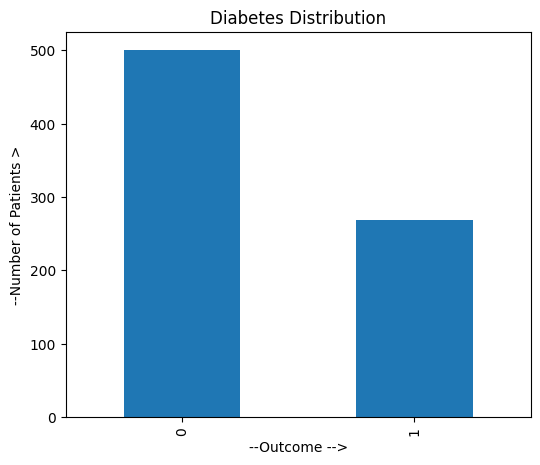

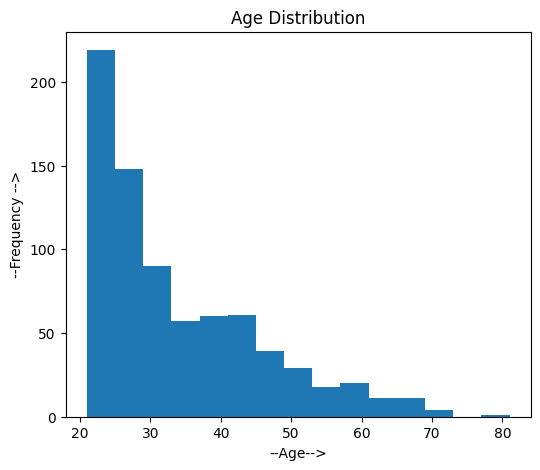

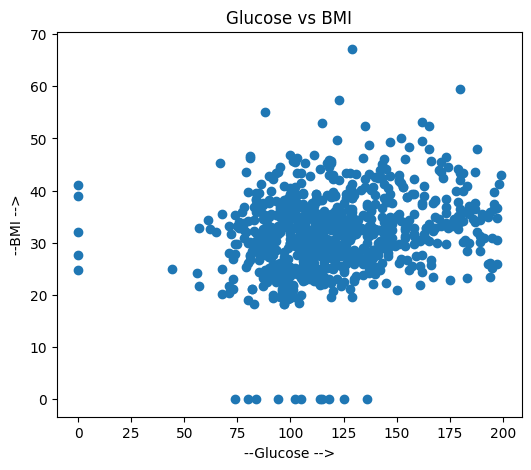

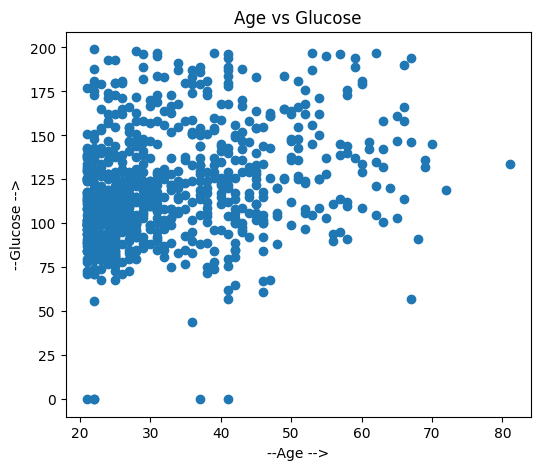

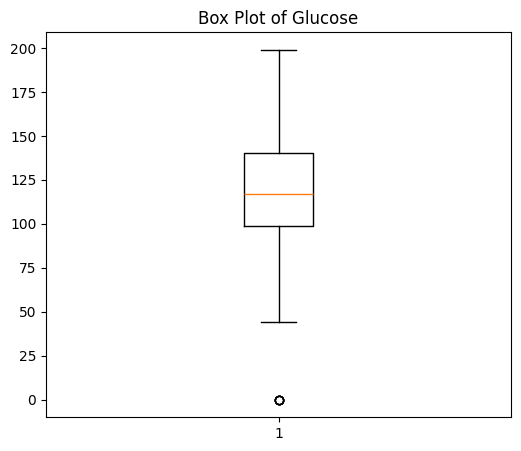

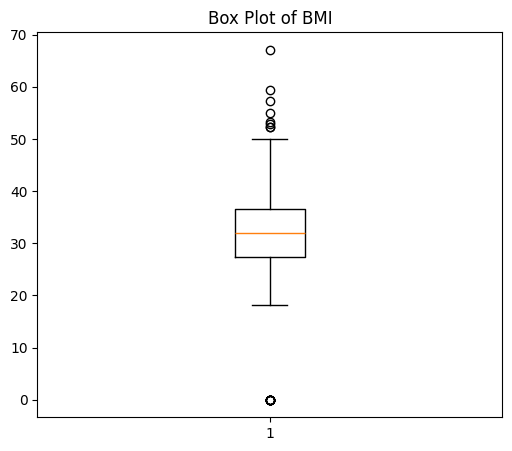

                          Pregnancies   Glucose  BloodPressure  SkinThickness  \
Pregnancies                  1.000000  0.129459       0.141282      -0.081672   
Glucose                      0.129459  1.000000       0.152590       0.057328   
BloodPressure                0.141282  0.152590       1.000000       0.207371   
SkinThickness               -0.081672  0.057328       0.207371       1.000000   
Insulin                     -0.073535  0.331357       0.088933       0.436783   
BMI                          0.017683  0.221071       0.281805       0.392573   
DiabetesPedigreeFunction    -0.033523  0.137337       0.041265       0.183928   
Age                          0.544341  0.263514       0.239528      -0.113970   
Outcome                      0.221898  0.466581       0.065068       0.074752   

                           Insulin       BMI  DiabetesPedigreeFunction  \
Pregnancies              -0.073535  0.017683                 -0.033523   
Glucose                   0.331357  0.221

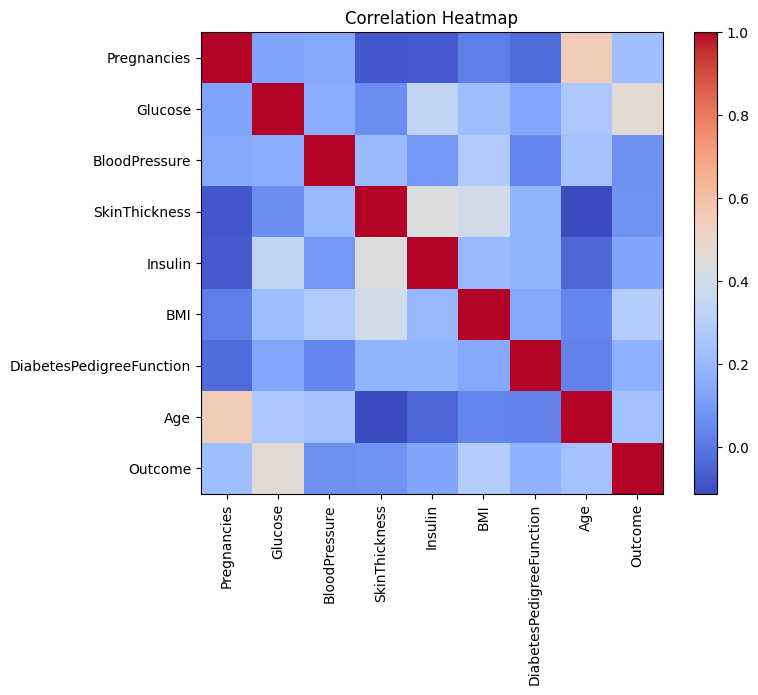

Input Features:
   Pregnancies  Glucose  BloodPressure  SkinThickness  Insulin   BMI  \
0            6      148             72             35        0  33.6   
1            1       85             66             29        0  26.6   
2            8      183             64              0        0  23.3   
3            1       89             66             23       94  28.1   
4            0      137             40             35      168  43.1   

   DiabetesPedigreeFunction  Age  
0                     0.627   50  
1                     0.351   31  
2                     0.672   32  
3                     0.167   21  
4                     2.288   33  

Target Variable:
0    1
1    0
2    1
3    0
4    1
Name: Outcome, dtype: int64
Shape of X: (768, 8)
Shape of y: (768,)
Feature Scaling Completed Successfully!
Training Data Shape: (614, 8)
Testing Data Shape: (154, 8)
Model Trained Successfully!
                    Feature  Coefficient
0               Pregnancies     0.064376
1          

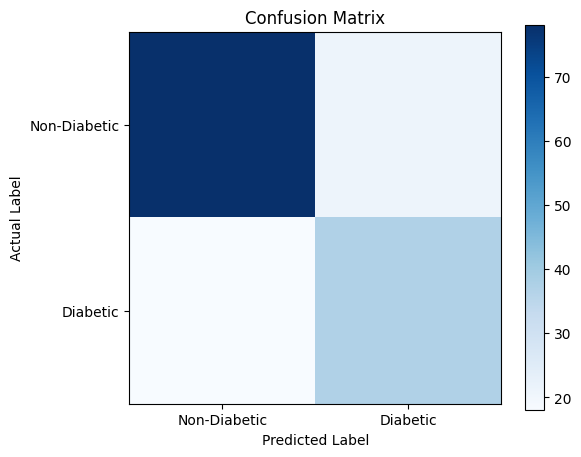

              precision    recall  f1-score   support

           0       0.81      0.79      0.80        99
           1       0.64      0.67      0.65        55

    accuracy                           0.75       154
   macro avg       0.73      0.73      0.73       154
weighted avg       0.75      0.75      0.75       154

[[0.7241302  0.2758698 ]
 [0.81156219 0.18843781]
 [0.88551665 0.11448335]
 [0.83645744 0.16354256]
 [0.52847618 0.47152382]
 [0.55818622 0.44181378]
 [0.98454142 0.01545858]
 [0.33922616 0.66077384]
 [0.45853844 0.54146156]
 [0.22267004 0.77732996]]
The patient is likely to be Non-Diabetic.
Prediction Probability:
[[9.99895567e-01 1.04433075e-04]]


In [ ]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

print("Libraries Imported Successfully!")
project_path= os.getcwd()
print('Project Path=', project_path)
file_path = project_path + '\\diabetes_data.xlsx'
print('file path=', file_path)

df= pd.read_excel(file_path)
print(df)
df.info()
df.describe()

# Remove Duplicate Records
df = df.drop_duplicates()
print("Dataset Shape After Removing Duplicates:")
print(df.shape)

# Count of Target Variable
print(df["Outcome"].value_counts())

#Bar chart of outcome
plt.figure(figsize=(6,5))
df["Outcome"].value_counts().plot(kind="bar")
plt.title("Diabetes Distribution")
plt.xlabel("--Outcome -->")
plt.ylabel("--Number of Patients >")
plt.show()

#Histogram of age
plt.figure(figsize=(6,5))
plt.hist(df["Age"], bins=15)
plt.title("Age Distribution")
plt.xlabel("--Age-->")
plt.ylabel("--Frequency -->")
plt.show()

#scatter plot (Glucose vs BMI)
plt.figure(figsize=(6,5))
plt.scatter(df["Glucose"], df["BMI"])
plt.title("Glucose vs BMI")
plt.xlabel("--Glucose -->")
plt.ylabel("--BMI -->")
plt.show()

#scatter plot (Age vs Glucose)
plt.figure(figsize=(6,5))
plt.scatter(df["Age"], df["Glucose"])
plt.title("Age vs Glucose")
plt.xlabel("--Age -->")
plt.ylabel("--Glucose -->")
plt.show()

# box plot of Glucose and BMI
plt.figure(figsize=(6,5))
plt.boxplot(df["Glucose"])
plt.title("Box Plot of Glucose")
plt.show()

plt.figure(figsize=(6,5))
plt.boxplot(df["BMI"])
plt.title("Box Plot of BMI")
plt.show()

correlation = df.corr()
print(correlation)
plt.figure(figsize=(8,6))
plt.imshow(correlation, cmap="coolwarm")
plt.colorbar()
plt.xticks(range(len(correlation.columns)), correlation.columns, rotation=90)
plt.yticks(range(len(correlation.columns)), correlation.columns)
plt.title("Correlation Heatmap")
plt.show()

# Input Features (Independent Variables)
X = df.drop("Outcome", axis=1)

# Target Variable (Dependent Variable)
y = df["Outcome"]

print("Input Features:")
print(X.head())

print("\nTarget Variable:")
print(y.head())

print("Shape of X:", X.shape)
print("Shape of y:", y.shape)

# Feature Scaling
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
print("Feature Scaling Completed Successfully!")

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

print("Training Data Shape:", X_train.shape)
print("Testing Data Shape:", X_test.shape)

model = LogisticRegression(max_iter=1000)
model.fit(X_train, y_train)

print("Model Trained Successfully!")

coef_df = pd.DataFrame({
    "Feature": X.columns,
    "Coefficient": model.coef_[0]
})
print(coef_df)
print("Intercept:", model.intercept_[0])

y_pred = model.predict(X_test)
print("Predicted Values:")
print(y_pred)
comparison = pd.DataFrame({
    "Actual": y_test.values,
    "Predicted": y_pred
})

comparison.head(10)

# Calculate Accuracy
accuracy = accuracy_score(y_test, y_pred)
print("Model Accuracy:", round(accuracy * 100, 2), "%")

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
print("Confusion Matrix:")
print(cm)

# Confusion Matrix Heatmap
plt.figure(figsize=(6,5))
plt.imshow(cm, cmap='Blues')
plt.title("Confusion Matrix")
plt.xlabel("Predicted Label")
plt.ylabel("Actual Label")
plt.xticks([0,1], ["Non-Diabetic","Diabetic"])
plt.yticks([0,1], ["Non-Diabetic","Diabetic"])
plt.colorbar()
plt.show()

# Classification Report
report = classification_report(y_test, y_pred)
print(report)

# Probability Prediction
probabilities = model.predict_proba(X_test)
print(probabilities[:10])

# New Patient Data
new_patient = pd.DataFrame([[2,120,70,20,79,25.3,0.45,35]], columns= X.columns)
# Scale the New Patient Data
new_patient_scaled = scaler.transform(new_patient)
new_patient_scaled = pd.DataFrame(new_patient_scaled, columns= X.columns)

# Predict
prediction = model.predict(new_patient_scaled)
if prediction[0] == 1:
    print("The patient is likely to be Diabetic.")
else:
    print("The patient is likely to be Non-Diabetic.")
probability = model.predict_proba(new_patient_scaled)
print("Prediction Probability:")
print(probability)

#conclusion
In this project, a Logistic Regression model was developed to predict whether a patient is diabetic based on medical attributes such as glucose level, BMI, age, blood pressure, insulin level, and other health-related features. The dataset was explored, cleaned, visualized, and scaled before training the model. After evaluation using accuracy, confusion matrix, and classification report, the model demonstrated good performance in classifying diabetic and non-diabetic patients. This project highlights how machine learning can support early diabetes prediction and assist healthcare professionals in making informed decisions.